## Demo: Conservative post-CV adjustment (linear stepping vs bracket + bisection)

This notebook demonstrates why the old **linear stepping** conservative adjustment can fail when Optuna/CV picks an extremely large `norm_constraint` (e.g. due to highly correlated bases), and how the new **bracket + log-bisection** method still achieves the same goal:

> Find the **smallest** `norm_constraint` such that
> \( \text{CV\_LL}(\text{nc}) \ge \max\_\text{CV\_LL} - k \cdot \text{SD} \).

To make the behavior deterministic and easy to see, we use a *toy* tuner with a synthetic CV log-likelihood function.


In [1]:
import pandas as pd

from haldensity.censoring.tuners._base import BaseCensoredInitTuner


class ToyTuner(BaseCensoredInitTuner):
    """A deterministic tuner to isolate conservative-adjustment behavior.

    We override CV scoring so we can precisely control CV_LL(nc).

    Constructed so that:
    - Optuna reports a very large best norm_constraint (e.g. 80_000).
    - But the *smallest* norm_constraint still above the conservative threshold is 8.

    In particular we define a plateau:
      CV_LL(nc) = 100 if nc >= 8, else 90
    with SD fixed at 10.

    With k=0.05, threshold = 100 - 0.05*10 = 99.5, so any nc >= 8 is acceptable.
    """

    def _suggest_params(self, trial):
        raise NotImplementedError("ToyTuner does not run Optuna in this demo")

    def _evaluate_fold(self, train_df, val_df, params):
        raise NotImplementedError("ToyTuner does not run fold fitting in this demo")

    def _fit_final_estimator(self, params):
        return params

    def _compute_cv_score_with_sd(self, norm_constraint, basis_order):
        mean_ll = 100.0 if float(norm_constraint) >= 8.0 else 90.0
        sd_ll = 10.0
        fold_scores = [mean_ll] * int(self.cv_folds)
        return mean_ll, sd_ll, fold_scores


/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Fake the Optuna result: a wildly large best norm_constraint.
# (This is the situation where linear stepping tends to get "stuck" near huge values.)
optuna_best = {"norm_constraint": 80_000.0, "basis_order": 0}

data = pd.DataFrame({"dummy": [0]})

from pprint import pprint

try:
    from IPython.display import display as _ip_display  # notebook-friendly

    def display(x):
        _ip_display(x)

except Exception:
    # Minimal fallback if run outside IPython.
    def display(x):
        print(x)


# --- Linear stepping (legacy) ---
lin = ToyTuner(
    data=data,
    cv_folds=5,
    silent=True,
    use_conservative_adjustment=True,
    conservative_method="linear",
    conservative_k_percent=0.05,
    conservative_step_pct=0.02,  # 2% of optuna best per step
    conservative_max_steps=50,
)
lin.optuna_params = optuna_best
lin_params = lin._apply_conservative_adjustment()

# --- Bracket + bisection (new default) ---
bis = ToyTuner(
    data=data,
    cv_folds=5,
    silent=True,
    use_conservative_adjustment=True,
    conservative_method="bisection",
    conservative_k_percent=0.05,
    conservative_step_pct=0.02,  # interpreted as relative tolerance for bisection stop
    conservative_bracket_factor=0.5,
    conservative_max_steps=50,
)
bis.optuna_params = optuna_best
bis_params = bis._apply_conservative_adjustment()

print("Linear conservative params:")
pprint(lin_params)
print("Bisection conservative params:")
pprint(bis_params)

# Show what each method evaluated.
lin_df = pd.DataFrame(lin.adjustment_results)
bis_df = pd.DataFrame(bis.adjustment_results)

print("\nLinear evaluated norm_constraints (last rows):")
display(lin_df.tail(10))

print("\nBisection evaluated norm_constraints (all rows):")
display(bis_df)


Linear conservative params:
{'basis_order': 0, 'norm_constraint': 1600.0}
Bisection conservative params:
{'basis_order': 0, 'norm_constraint': 8.035915420673659}

Linear evaluated norm_constraints (last rows):


,step,norm_constraint,cv_ll,cv_sd,above_threshold,method,threshold
40,40,16000.0,100.0,10.0,True,linear,99.5
41,41,14400.0,100.0,10.0,True,linear,99.5
42,42,12800.0,100.0,10.0,True,linear,99.5
43,43,11200.0,100.0,10.0,True,linear,99.5
44,44,9600.0,100.0,10.0,True,linear,99.5
45,45,8000.0,100.0,10.0,True,linear,99.5
46,46,6400.0,100.0,10.0,True,linear,99.5
47,47,4800.0,100.0,10.0,True,linear,99.5
48,48,3200.0,100.0,10.0,True,linear,99.5
49,49,1600.0,100.0,10.0,True,linear,99.5



Bisection evaluated norm_constraints (all rows):


,step,norm_constraint,cv_ll,cv_sd,above_threshold,method,threshold
0,0,80000.000000,100.0,10.0,True,bisection,99.5
1,1,40000.000000,100.0,10.0,True,bisection,99.5
2,2,20000.000000,100.0,10.0,True,bisection,99.5
3,3,10000.000000,100.0,10.0,True,bisection,99.5
4,4,5000.000000,100.0,10.0,True,bisection,99.5
5,5,2500.000000,100.0,10.0,True,bisection,99.5
6,6,1250.000000,100.0,10.0,True,bisection,99.5
7,7,625.000000,100.0,10.0,True,bisection,99.5
8,8,312.500000,100.0,10.0,True,bisection,99.5
9,9,156.250000,100.0,10.0,True,bisection,99.5


### What you should see

- **Linear** will step down by 2% of 80,000 (= 1,600) each time and never evaluates values near 8 before it hits the stopping condition. So it returns something like **1,600** (still huge).
- **Bisection** first brackets by halving: 80,000 → 40,000 → … → 9.765625 (still OK) → 4.8828125 (fails), then bisects in log-space and returns something near **8**.

This is exactly the failure mode you described: when the Optuna optimum is huge due to correlated bases, the linear “forward move” is too coarse in *absolute* terms to ever reach the plausible region.


In [8]:
import numpy as np
import matplotlib.pyplot as plt

from haldensity.censoring.right.estimators import RightCensoredInitEstimator
from haldensity.censoring.right.km import KaplanMeier
from haldensity.censoring.right.weights import compute_ipcw_weights
from haldensity.utils import TruncatedGMM


def make_right_censored_data(n: int = 400, seed: int = 7):
    rng = np.random.default_rng(seed)

    sampler = TruncatedGMM(
        components=[
            {"mean": 0.2, "std": 0.05, "lower": 0.0, "upper": 1.0},
            {"mean": 0.55, "std": 0.07, "lower": 0.0, "upper": 1.0},
            {"mean": 0.82, "std": 0.04, "lower": 0.0, "upper": 1.0},
        ],
        weights=[0.35, 0.35, 0.30],
    )

    # Event times in [0, 1]
    t_event = sampler.generate_samples(n)

    # Independent censoring times in [0, 1]
    t_cens = rng.uniform(0.0, 1.0, size=n)

    t_obs = np.minimum(t_event, t_cens)
    delta = (t_event <= t_cens).astype(int)

    df = pd.DataFrame({"T": t_obs, "Delta": delta})
    return df, sampler


data_rc, truth_sampler = make_right_censored_data(n=100, seed=11)

# IPCW weights computed from KM estimate of censoring survival
km = KaplanMeier().fit(data_rc, time_col="T", delta_col="Delta")
T_vals = np.asarray(data_rc["T"].values, dtype=float)
Delta_vals = np.asarray(data_rc["Delta"].values, dtype=int)
w_ipcw = compute_ipcw_weights(T_vals, Delta_vals, lambda t: np.atleast_1d(km.predict(t)))

unc = Delta_vals == 1
X_unc = pd.DataFrame({"W1": T_vals[unc]})
w_unc = w_ipcw[unc]

print("n total:", len(data_rc), "n uncensored:", int(unc.sum()))
print("linear nc:", float(lin_params["norm_constraint"]))
print("bisection nc:", float(bis_params["norm_constraint"]))


n total: 100 n uncensored: 43
linear nc: 1600.0
bisection nc: 8.035915420673659


In [9]:
# Fit IPCW-HAL-MLE initial estimators with the two norm_constraints
basis_order = 0

est_linear = RightCensoredInitEstimator(
    norm_constraint=float(lin_params["norm_constraint"]),
    basis_order=basis_order,
    n_grid_points=250,
    solver="ECOS",
    use_secondary_solver=True,
)

est_bisect = RightCensoredInitEstimator(
    norm_constraint=float(bis_params["norm_constraint"]),
    basis_order=basis_order,
    n_grid_points=250,
    solver="ECOS",
    use_secondary_solver=True,
)

est_linear.fit(X_unc, sample_weights=w_unc)
est_bisect.fit(X_unc, sample_weights=w_unc)

res_lin = est_linear.get_results()
res_bis = est_bisect.get_results()

print(
    "linear: n_selected_knots=",
    res_lin["n_selected_knots"],
    "norm_constraint=",
    float(getattr(est_linear, "norm_constraint", getattr(est_linear, "_norm_constraint", float('nan')))),
)
print(
    "bisect: n_selected_knots=",
    res_bis["n_selected_knots"],
    "norm_constraint=",
    float(getattr(est_bisect, "norm_constraint", getattr(est_bisect, "_norm_constraint", float('nan')))),
)


linear: n_selected_knots= 13 norm_constraint= 1600.0
bisect: n_selected_knots= 13 norm_constraint= 8.035915420673659


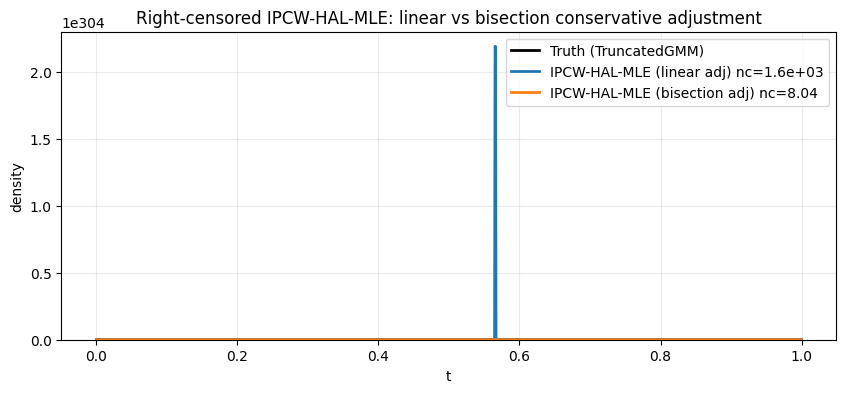

In [10]:
# Visualize densities
x = np.linspace(0.001, 0.999, 1500)

f_lin = np.asarray(est_linear.get_density_at_points(x), dtype=float)
f_bis = np.asarray(est_bisect.get_density_at_points(x), dtype=float)
f_true = np.asarray(truth_sampler.compute_density(x), dtype=float)

plt.figure(figsize=(10, 4))
plt.plot(x, f_true, color="black", lw=2, label="Truth (TruncatedGMM)")
plt.plot(x, f_lin, lw=2, label=f"IPCW-HAL-MLE (linear adj) nc={float(lin_params['norm_constraint']):.3g}")
plt.plot(x, f_bis, lw=2, label=f"IPCW-HAL-MLE (bisection adj) nc={float(bis_params['norm_constraint']):.3g}")

plt.ylim(bottom=0)
plt.xlabel("t")
plt.ylabel("density")
plt.title("Right-censored IPCW-HAL-MLE: linear vs bisection conservative adjustment")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


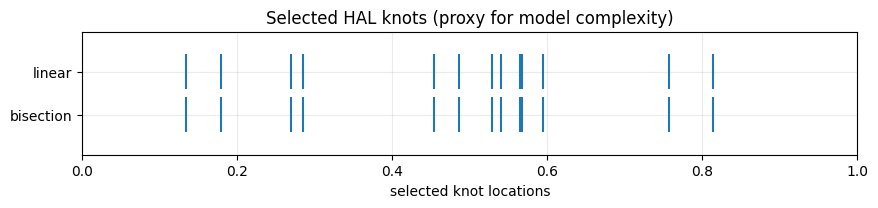

In [11]:
# Optional: compare roughness / complexity via selected knots
lin_knots = np.asarray(res_lin["grid_points_hal_selected"], dtype=float)
bis_knots = np.asarray(res_bis["grid_points_hal_selected"], dtype=float)

plt.figure(figsize=(10, 1.6))
plt.eventplot([lin_knots, bis_knots], lineoffsets=[1, 0], linelengths=[0.8, 0.8])
plt.yticks([1, 0], ["linear", "bisection"])
plt.xlim(0, 1)
plt.xlabel("selected knot locations")
plt.title("Selected HAL knots (proxy for model complexity)")
plt.grid(alpha=0.25)
plt.show()
